In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [20]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [21]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [22]:
dados.columns = dados.columns.str.strip()

In [23]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [24]:
df_indices = dados[[
    "Data",
    "W/m² - Radiação",
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
]].copy()

df_indices["Data"] = pd.to_datetime(df_indices["Data"])
df_indices = df_indices.sort_values("Data").set_index("Data")

In [25]:
df_indices.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação
Data,,,
1984-01-01,211.801254,25.419519,0.989776
1984-01-02,204.752853,26.399133,0.166336
1984-01-03,217.430527,26.202539,0.256648
1984-01-04,222.075912,26.720331,0.000000
1984-01-05,220.100525,27.286249,0.000000


In [26]:
colunas_norm = [
    "W/m² - Radiação",
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
]

df_norm = (
    df_indices[colunas_norm] - df_indices[colunas_norm].min()
 ) / (df_indices[colunas_norm].max() - df_indices[colunas_norm].min())

In [27]:
df_norm.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação
Data,,,
1984-01-01,0.701174,0.538083,0.018626
1984-01-02,0.655148,0.676959,0.003130
1984-01-03,0.737933,0.649089,0.004830
1984-01-04,0.768267,0.722494,0.000000
1984-01-05,0.755368,0.802722,0.000000


In [28]:
df_indices["IPS"] = df_norm["W/m² - Radiação"]

In [29]:
df_indices["IECS"] = (
    df_norm["W/m² - Radiação"] +
    df_norm["C° - Temperatura Média"] -
    df_norm["mm/dia - Precipitação"]
)

In [30]:
df_indices[["IPS", "IECS"]].head()

,IPS,IECS
Data,,
1984-01-01,0.701174,1.220631
1984-01-02,0.655148,1.328977
1984-01-03,0.737933,1.382192
1984-01-04,0.768267,1.490761
1984-01-05,0.755368,1.558090


In [31]:
df_indices[["IPS", "IECS"]].describe()

,IPS,IECS
count,11322.000000,11322.000000
mean,0.529163,0.979109
std,0.173776,0.364740
min,0.000000,-0.539176
25%,0.397430,0.701562
50%,0.538515,1.015948
75%,0.663119,1.272415
max,1.000000,1.966594


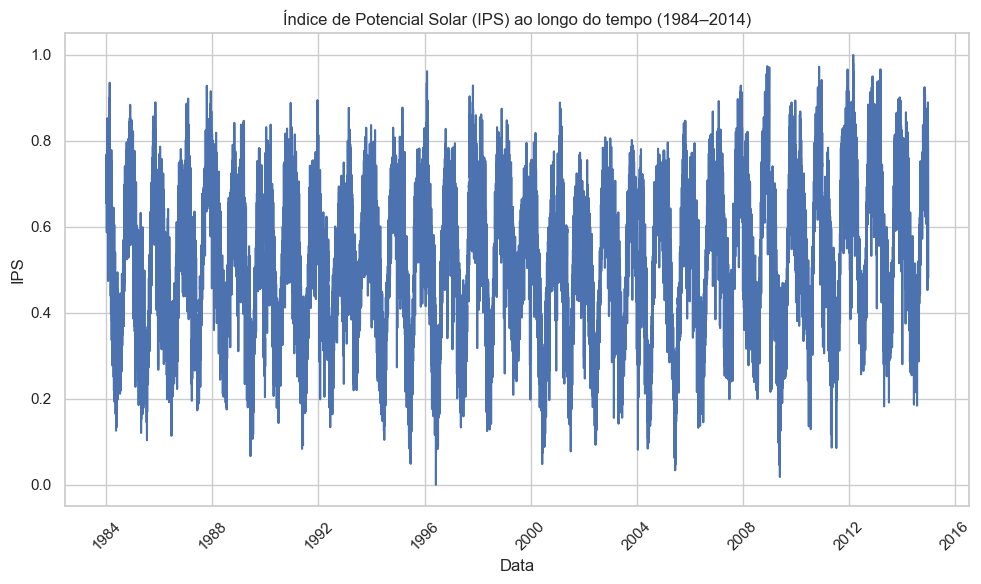

In [32]:
plt.plot(df_indices["IPS"])

plt.title("Índice de Potencial Solar (IPS) ao longo do tempo (1984–2014)")
plt.xlabel("Data")
plt.ylabel("IPS")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Interpretação (IPS ao longo do tempo).** O IPS é a radiação normalizada (0 a 1) e, por isso, funciona como uma medida direta do potencial solar climático.

- Picos de IPS indicam períodos com **maior disponibilidade de radiação** (condições mais favoráveis ao aproveitamento fotovoltaico).
- Vales de IPS indicam períodos com **menor disponibilidade de radiação** (condições menos favoráveis).
- Oscilações recorrentes ao longo dos anos sugerem **ciclos sazonais** e variações interanuais na disponibilidade de radiação.

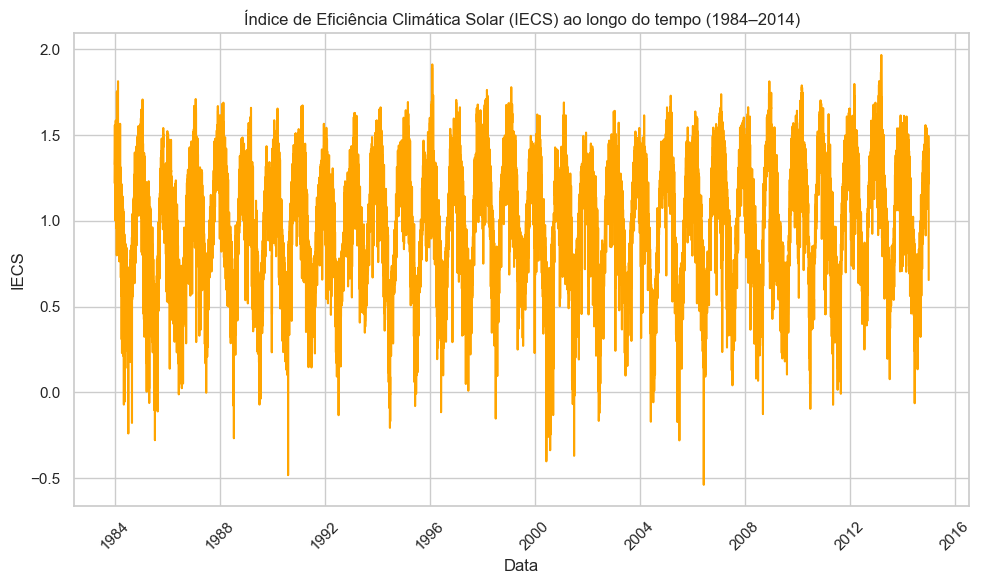

In [33]:
plt.plot(df_indices["IECS"], color="orange")

plt.title("Índice de Eficiência Climática Solar (IECS) ao longo do tempo (1984–2014)")
plt.xlabel("Data")
plt.ylabel("IECS")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Interpretação (IECS ao longo do tempo).** O IECS combina radiação e temperatura (efeitos positivos) e precipitação (efeito negativo), representando uma medida sintética de quão favorável o clima está para a eficiência solar.

- Valores mais altos do IECS indicam meses/períodos com **radiação e temperatura relativamente altas** e/ou **precipitação relativamente baixa**.
- Valores baixos (ou negativos) indicam períodos em que a **precipitação pesa mais**, reduzindo a eficiência climática solar esperada.
- A amplitude maior do IECS (comparada ao IPS) é esperada, pois o índice agrega múltiplas variáveis com sinais opostos.

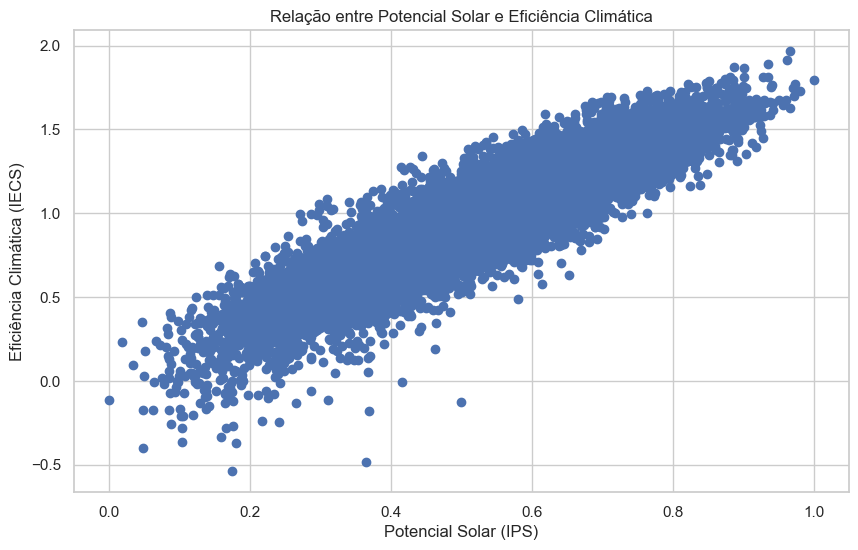

In [34]:
plt.scatter(df_indices["IPS"], df_indices["IECS"])

plt.xlabel("Potencial Solar (IPS)")
plt.ylabel("Eficiência Climática (IECS)")

plt.title("Relação entre Potencial Solar e Eficiência Climática")

plt.show()

**Interpretação (Dispersão IPS × IECS).** Este gráfico mostra como o potencial solar (IPS) se relaciona com a eficiência climática solar (IECS).

- Uma tendência geral crescente indica que, quando o **IPS aumenta**, o **IECS tende a aumentar** também, sugerindo condições climáticas mais favoráveis no conjunto.
- A dispersão dos pontos mostra que, mesmo com IPS alto, o IECS pode variar por causa do efeito da **precipitação** e da **temperatura** (que entram explicitamente no IECS).
- Pontos com IECS relativamente baixo para um mesmo IPS sugerem períodos em que a **precipitação** foi mais elevada, reduzindo a eficiência climática mesmo com radiação moderada/alta.

## 6. Índices Climáticos para Energia Solar

Nesta etapa, foram construídos dois índices climáticos com o objetivo de sintetizar, de forma simples, o comportamento das variáveis mais importantes para o aproveitamento da energia solar: a **radiação**, a **temperatura média** e a **precipitação**.

A ideia dessa etapa é transformar variáveis climáticas em medidas resumidas que ajudem a interpretar, ao longo do tempo, quando as condições estão mais ou menos favoráveis ao uso da energia solar no período **1984–2014**.

---

## 6.1 Preparação dos dados

Inicialmente, foram selecionadas três variáveis do banco de dados:

- **W/m² - Radiação**
- **C° - Temperatura Média**
- **mm/dia - Precipitação**

Em seguida, os dados foram normalizados pela fórmula min-max:

**X_normalizado = (X - Xmín) / (Xmáx - Xmín)**

Esse procedimento foi necessário para colocar todas as variáveis na mesma escala, variando entre **0 e 1**, evitando que uma variável com valores maiores dominasse o cálculo dos índices.

---

## 6.2 Índice de Potencial Solar (IPS)

O **Índice de Potencial Solar (IPS)** foi definido diretamente a partir da variável de radiação normalizada:

**IPS = Radiação normalizada**

Esse índice representa, de forma simples, o potencial solar disponível em cada data observada. Quanto maior o valor do IPS, maior a disponibilidade de radiação solar e, portanto, maior o potencial para aproveitamento fotovoltaico.

### Estatísticas descritivas do IPS

- **Média:** 0,529
- **Desvio padrão:** 0,174
- **Mínimo:** 0,000
- **1º quartil:** 0,397
- **Mediana:** 0,539
- **3º quartil:** 0,663
- **Máximo:** 1,000

### Interpretação do IPS

Os resultados mostram que o IPS variou ao longo da série histórica, refletindo a alternância entre períodos de maior e menor disponibilidade de radiação. Como esse índice depende apenas da radiação, ele funciona como uma medida direta do potencial solar climático.

---

## 6.3 Índice de Eficiência Climática Solar (IECS)

O **Índice de Eficiência Climática Solar (IECS)** foi construído combinando três componentes climáticos:

**IECS = Radiação normalizada + Temperatura normalizada - Precipitação normalizada**

A lógica desse índice é a seguinte:

- **radiação elevada** contribui positivamente;
- **temperatura mais alta** tende a indicar condições atmosféricas mais secas e favoráveis;
- **precipitação elevada** contribui negativamente, pois geralmente está associada à nebulosidade e à redução da radiação disponível.

### Estatísticas descritivas do IECS

- **Média:** 0,979
- **Desvio padrão:** 0,365
- **Mínimo:** -0,539
- **1º quartil:** 0,702
- **Mediana:** 1,016
- **3º quartil:** 1,272
- **Máximo:** 1,967

### Interpretação do IECS

O IECS apresentou maior amplitude que o IPS, pois considera simultaneamente fatores favoráveis e desfavoráveis. Valores mais altos indicam condições climáticas mais adequadas à eficiência solar, enquanto valores baixos ou negativos representam situações menos favoráveis, geralmente associadas a maior precipitação e menor contribuição relativa da radiação.

---

## 6.4 Análise gráfica dos índices

### Comportamento temporal do IPS

O gráfico do IPS ao longo do tempo (**1984–2014**) mostrou oscilações frequentes, indicando que o potencial solar varia continuamente na série temporal. Já é possível notar a presença de ciclos e flutuações recorrentes, associados a padrões sazonais e variações interanuais.

### Comportamento temporal do IECS

O gráfico do IECS também apresentou variação cíclica ao longo do tempo, com amplitude maior do que o IPS, justamente porque incorpora mais de uma variável climática. Isso mostra que a eficiência climática solar depende não apenas da radiação isolada, mas também da combinação entre temperatura e precipitação.

### Relação entre IPS e IECS

No gráfico de dispersão entre IPS e IECS, observou-se uma **relação positiva clara**. Isso indica que, em geral, valores mais altos de potencial solar também estão associados a melhores condições climáticas de eficiência solar.

Em termos práticos, isso significa que quando a radiação aumenta, tende também a haver um cenário climático mais favorável ao aproveitamento solar, principalmente quando a precipitação permanece baixa.

---

## 6.5 Interpretação prática da etapa

Essa etapa foi importante porque transformou variáveis climáticas isoladas em **indicadores sintéticos**, mais fáceis de interpretar. Em vez de analisar apenas colunas separadas de radiação, temperatura e precipitação, os índices permitem resumir a condição climática para energia solar de forma mais objetiva.

De maneira prática:

- o **IPS** mostra o quanto existe de potencial solar disponível;
- o **IECS** mostra o quanto o clima, como um todo, está favorecendo esse aproveitamento.

---

## 6.6 Conclusão da etapa

A construção dos índices climáticos para energia solar foi adequada para complementar a análise exploratória e a modelagem estatística anteriores. O **IPS** permitiu representar diretamente o potencial solar com base na radiação, enquanto o **IECS** incorporou o efeito conjunto de variáveis climáticas favoráveis e desfavoráveis.

Os resultados mostram que os dois índices conseguem representar bem a variabilidade climática da série e ajudam a interpretar, de forma mais resumida, as condições de aproveitamento da energia solar na região estudada.